In [3]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import time
import numpy as np
import matplotlib.pyplot as plt
LOG.propagate = False

In [4]:
LOG.debug("debug")
LOG.info("info")
LOG.warning("warning")
LOG.error("error")
LOG.critical("critical")

2025-02-19 17:10:40,370 | INFO     |: info
2025-02-19 17:10:40,371 | WARNING  |: warning
2025-02-19 17:10:40,371 | ERROR    |: error
2025-02-19 17:10:40,372 | CRITICAL |: critical


In [5]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()

2025-02-19 17:10:44,989 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:e0:ec:f0:72:02
2025-02-19 17:10:49,243 | INFO     |: Connected to c0:e0:ec:f0:72:02


C:\CornellCourse\ECE5160\ble_robot_1.2\ble_python\base_ble.py:104: FutureWarning: This method will be removed future version, pass the callback to the BleakClient constructor instead.
  self.client.set_disconnected_callback(self.disconnect_handler)


## Receive data from the Artemis board

In [4]:
## lab 1

In [5]:
#1.
ble.send_command(CMD.ECHO, "HiHello")
ble.receive_string(ble.uuid['RX_STRING'])

'Robot says -> HiHello :)'

In [6]:
#2.
ble.send_command(CMD.SEND_THREE_FLOATS, "1|2|3")
ble.receive_string(ble.uuid['RX_STRING'])

'Received: 1.000, 2.000, 3.000'

In [7]:
#3.
ble.send_command(CMD.GET_TIME_MILLIS, "")
time_str = ble.receive_string(ble.uuid['RX_STRING'])
print("Time string from Artemis:", time_str)

Time string from Artemis: T:259076


In [8]:
#4.
def rx_string_notification_handler(uuid, byte_array):
    # Convert the incoming bytearray to a string
    msg = ble.bytearray_to_string(byte_array)
    print(f"Notification => Received string: {msg}")

In [9]:
# Start notification
ble.start_notify(ble.uuid['RX_STRING'], rx_string_notification_handler)
ble.send_command(CMD.GET_TIME_MILLIS, "")
ble.stop_notify(ble.uuid['RX_STRING'])

Notification => Received string: T:261709


In [10]:
# 5  
import time
# Global list to store the times we receive
timestamps = []
def rx_string_notification_handler(uuid, byte_array):
    msg = ble.bytearray_to_string(byte_array)
    # We expect something like "T:123456"
    if msg.startswith("T:"):
        # Extract the integer part
        t_val = int(msg[2:])
        # Record the arrival time on the PC side as well
        pc_time = time.time()  # seconds (float)
        timestamps.append((pc_time, t_val))  # store a tuple (pc_time, artemis_millis)
        print(f"Notification => {msg}, PC time: {pc_time}")
    else:
        print(f"Notification => {msg}")

In [ ]:
ble.start_notify(ble.uuid['RX_STRING'], rx_string_notification_handler)
# Clear the timestamps list before we start
timestamps.clear()
print("Requesting time stream from Artemis...")
ble.send_command(CMD.GET_TIME_STREAM, "")
# Because Artemis will block for ~5 seconds streaming,
# we wait a bit more on the Python side so we don't disconnect early
time.sleep(6) 

In [12]:
print(f"Received {len(timestamps)} time messages from Artemis.")
if len(timestamps) > 1:
    # The first PC arrival time
    t0 = timestamps[0][0]  # in seconds
    # The last PC arrival time
    t1 = timestamps[-1][0]
    duration = t1 - t0
    num_msgs = len(timestamps)
    rate = num_msgs / duration  # messages per second
    print(f"Received {num_msgs} messages in {duration:.2f}s => ~{rate:.2f} msgs/s")
else:
    print("No timestamps received.")

Received 202 time messages from Artemis.
Received 202 messages in 6.01s => ~33.62 msgs/s


In [14]:
# 6.
timestamps = []
def rx_string_notification_handler(uuid, byte_array):
    msg = ble.bytearray_to_string(byte_array)
    if msg.startswith("T:"):
        # e.g. T:12345
        t_val = int(msg[2:])
        timestamps.append(t_val)
        print(f"Notification => Received timestamp: {t_val}")
    else:
        print(f"Notification => Received: {msg}")

In [ ]:
# Start notifications
ble.start_notify(ble.uuid['RX_STRING'], rx_string_notification_handler)
# Clear old data
timestamps.clear()
# First store data on Artemis
ble.send_command(CMD.STORE_TIME_DATA, "")
# Now request that Artemis SEND_TIME_DATA
ble.send_command(CMD.SEND_TIME_DATA, "")

In [16]:
print("All done. Number of timestamps:", len(timestamps))

All done. Number of timestamps: 100


In [6]:
# 7.
time_data = []
temp_data = []
def rx_string_notification_handler(uuid, byte_array):
    msg = ble.bytearray_to_string(byte_array)
    if msg.startswith("T:"):
        content = msg[2:]  # e.g. "123456|25.50"
        # split at the '|'
        parts = content.split("|")  # ["123456", "25.50"]
        if len(parts) == 2:
            try:
                t_val   = int(parts[0])     # convert to integer time
                temp_val= float(parts[1])   # convert to float temperature
                time_data.append(t_val)
                temp_data.append(temp_val)
                print(f"Notification => time: {t_val}, temp: {temp_val}")
            except ValueError:
                print(f"Error parsing time/temp from: {msg}")
        else:
            print(f"Unexpected format: {msg}")
    else:
        print(f"Notification => Received: {msg}")

In [7]:
ble.start_notify(ble.uuid['RX_STRING'], rx_string_notification_handler)
time_data.clear()
temp_data.clear()
ble.send_command(CMD.STORE_TEMP_DATA, "")
time.sleep(5)
ble.send_command(CMD.GET_TEMP_READINGS, "")
time.sleep(3)

Notification => time: 340940, temp: 26.133
Notification => time: 340941, temp: 26.7
Notification => time: 340941, temp: 26.7
Notification => time: 340941, temp: 26.7
Notification => time: 340941, temp: 27.266
Notification => time: 340942, temp: 26.7
Notification => time: 340942, temp: 26.7
Notification => time: 340942, temp: 26.7
Notification => time: 340942, temp: 26.133
Notification => time: 340942, temp: 26.133
Notification => time: 340943, temp: 26.7
Notification => time: 340943, temp: 26.133
Notification => time: 340943, temp: 26.7
Notification => time: 340943, temp: 26.133
Notification => time: 340944, temp: 26.133
Notification => time: 340944, temp: 26.7
Notification => time: 340944, temp: 26.133
Notification => time: 340944, temp: 26.133
Notification => time: 340949, temp: 26.133
Notification => time: 340950, temp: 26.133
Notification => time: 340950, temp: 26.7
Notification => time: 340950, temp: 26.7
Notification => time: 340950, temp: 25.566
Notification => time: 340951, tem

In [6]:
# similary steps, rx_string_notification_handler and parsing msg,
# e.g. "123456|25.50",into 2 arrays
# then ble.send_command(CMD.STORE_TEMP_DATA, "") 
#      ble.send_command(CMD.GET_TEMP_READINGS, "") 
#Now check how many points arrived
print("Finished receiving data.")
print(f"Number of time readings: {len(time_data)}")
print(f"Number of temp readings: {len(temp_data)}")
ble.stop_notify(ble.uuid['RX_STRING'])

Finished receiving data.
Number of time readings: 100
Number of temp readings: 100


In [16]:
# 9.
num_tests = 50
times_short = []
times_long  = []
def read_reply():
    return ble.receive_string(ble.uuid['RX_STRING'])
# Testing 5-byte replies
for _ in range(num_tests):
    start_time = time.time()
    ble.send_command(CMD.SEND_SHORT_REPLY, "")
    reply = read_reply()  # Blocks until we receive the reply
    end_time = time.time()
    round_trip = end_time - start_time
    times_short.append(round_trip)
# Testing 120-byte replies
for _ in range(num_tests):
    start_time = time.time()
    ble.send_command(CMD.SEND_LONG_REPLY, "")
    reply = read_reply()
    end_time = time.time()
    round_trip = end_time - start_time
    times_long.append(round_trip)
# Now compute average times, data rates
avg_short = sum(times_short)/len(times_short)
avg_long  = sum(times_long)/len(times_long)
print(f"5-byte average RTT:  {avg_short*1000:.2f} ms")
print(f"120-byte average RTT:{avg_long*1000:.2f} ms")
# Effective throughput (one direction). 
throughput_short = 5 / avg_short  # bytes / seconds
throughput_long  = 120 / avg_long
print(f"Effective data rate for 5-byte:  {throughput_short:.2f} bytes/s")
print(f"Effective data rate for 120-byte:{throughput_long:.2f} bytes/s")

5-byte average RTT:  180.16 ms
120-byte average RTT:187.23 ms
Effective data rate for 5-byte:  27.75 bytes/s
Effective data rate for 120-byte:640.91 bytes/s


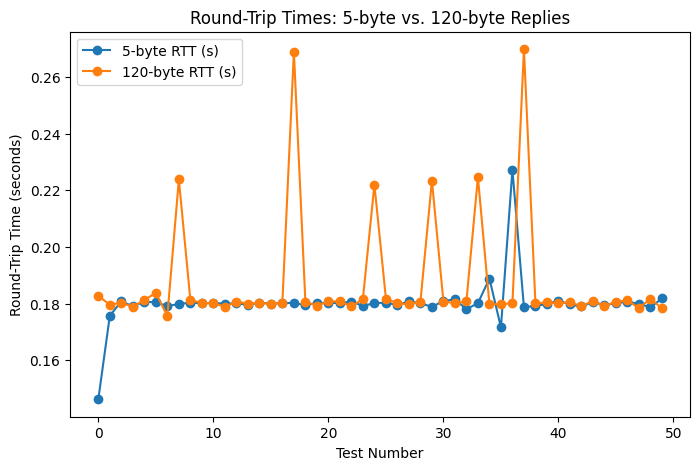

2025-01-30 11:08:46,441 | INFO     |: Disconnected from C0:E0:EC:F0:72:02


In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(times_short, label='5-byte RTT (s)', marker='o')
plt.plot(times_long, label='120-byte RTT (s)', marker='o')
plt.xlabel('Test Number')
plt.ylabel('Round-Trip Time (seconds)')
plt.title('Round-Trip Times: 5-byte vs. 120-byte Replies')
plt.legend()
plt.show()


Length 5 => Avg RTT: 176.21 ms, std: 11.13 ms
Length 10 => Avg RTT: 180.07 ms, std: 0.46 ms
Length 20 => Avg RTT: 179.90 ms, std: 0.86 ms
Length 50 => Avg RTT: 184.62 ms, std: 13.30 ms
Length 100 => Avg RTT: 193.55 ms, std: 19.92 ms
Length 120 => Avg RTT: 184.57 ms, std: 13.40 ms


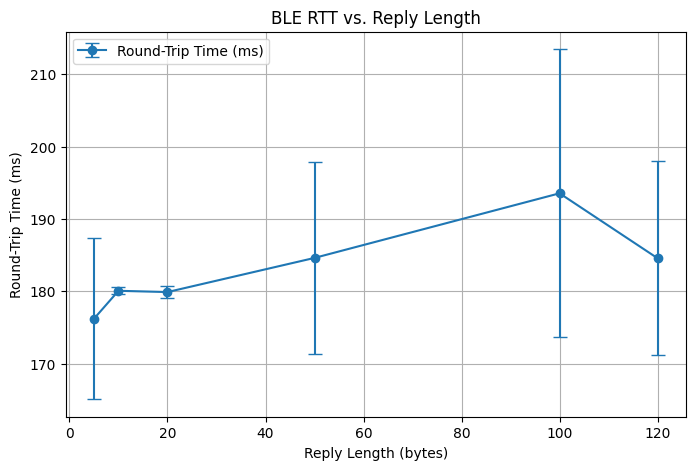

In [14]:
import time
import matplotlib.pyplot as plt
import numpy as np

from cmd_types import CMD
def measure_rtt(length, num_trials=10):
    rtts = []
    for _ in range(num_trials):
        start_time = time.time()
        # We send the length as a string argument
        ble.send_command(CMD.SIZED_REPLY, str(length))
        # Now read the reply
        # We expect a string of length 'length' from TX_STRING
        reply = ble.receive_string(ble.uuid['RX_STRING'])
        end_time = time.time()
        round_trip = end_time - start_time
        rtts.append(round_trip)
    return rtts
lengths_to_test = [5, 10, 20, 50, 100, 120]
# We'll store the average RTT and standard deviation for each length
avg_rtts = []
std_rtts = []
all_rtts = {}  

for length in lengths_to_test:
    rtts = measure_rtt(length, num_trials=10)
    mu = np.mean(rtts)
    sigma = np.std(rtts)
    avg_rtts.append(mu)
    std_rtts.append(sigma)
    all_rtts[length] = rtts
    print(f"Length {length} => Avg RTT: {mu*1000:.2f} ms, std: {sigma*1000:.2f} ms")

In [ ]:
plt.figure(figsize=(8,5))
plt.errorbar(lengths_to_test, [rt*1000 for rt in avg_rtts],
             yerr=[st*1000 for st in std_rtts],
             fmt='o-', capsize=5, label="Round-Trip Time (ms)")

plt.xlabel("Reply Length (bytes)")
plt.ylabel("Round-Trip Time (ms)")
plt.title("BLE RTT vs. Reply Length")
plt.legend()
plt.grid(True)
plt.show()

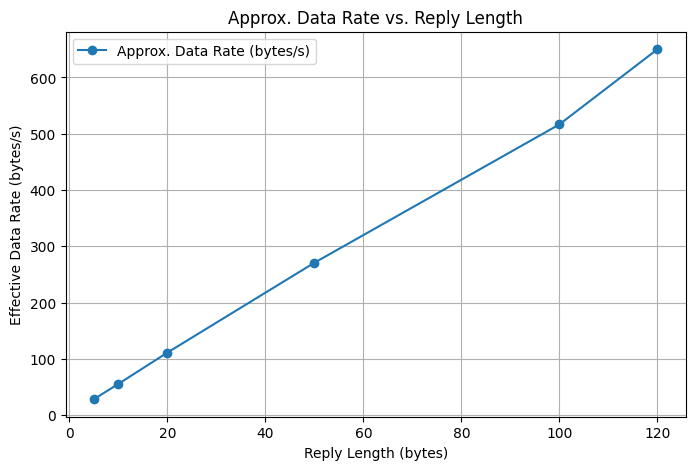

2025-02-04 14:07:36,431 | INFO     |: Disconnected from C0:E0:EC:F0:72:02


In [15]:
# If you want to compute an approximate data rate (one-way):
# We only measure round-trip time, but the payload is length bytes one-way.
# The request is small, so let's approximate data rate = length bytes / RTT.
# (If you want to be more precise, you might do bigger unidirectional tests.)
data_rates = [length / rt for (length, rt) in zip(lengths_to_test, avg_rtts)]
plt.figure(figsize=(8,5))
plt.plot(lengths_to_test, data_rates, 'o-', label="Approx. Data Rate (bytes/s)")
plt.xlabel("Reply Length (bytes)")
plt.ylabel("Effective Data Rate (bytes/s)")
plt.title("Approx. Data Rate vs. Reply Length")
plt.legend()
plt.grid(True)
plt.show()


Length 5 bytes => Avg RTT: 179.70 ms, Std Dev: 0.88 ms, Data Rate: 27.82 bytes/sec
Length 10 bytes => Avg RTT: 180.02 ms, Std Dev: 0.73 ms, Data Rate: 55.55 bytes/sec
Length 20 bytes => Avg RTT: 179.97 ms, Std Dev: 0.25 ms, Data Rate: 111.13 bytes/sec
Length 50 bytes => Avg RTT: 180.08 ms, Std Dev: 1.49 ms, Data Rate: 277.66 bytes/sec
Length 100 bytes => Avg RTT: 184.75 ms, Std Dev: 11.94 ms, Data Rate: 541.26 bytes/sec
Length 120 bytes => Avg RTT: 179.92 ms, Std Dev: 1.07 ms, Data Rate: 666.98 bytes/sec
Length 150 bytes => Avg RTT: 189.12 ms, Std Dev: 16.60 ms, Data Rate: 793.16 bytes/sec


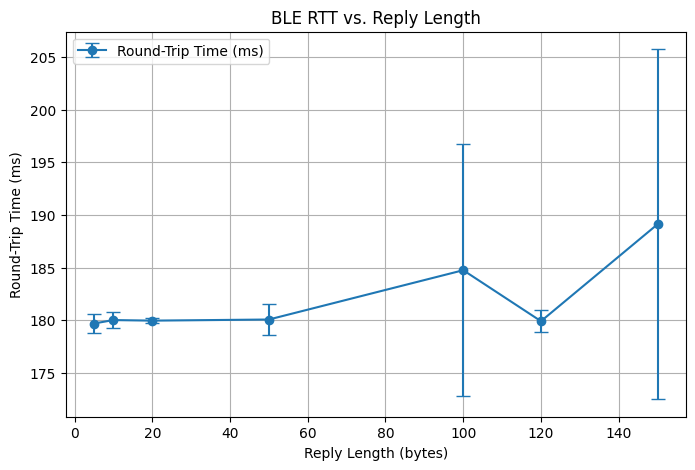

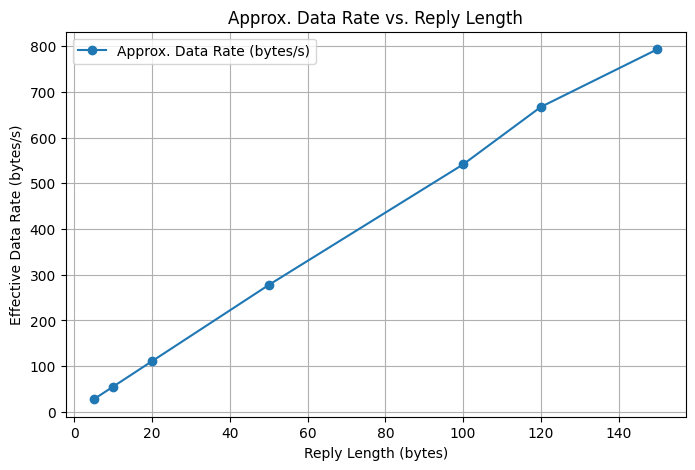

In [21]:
import time
import matplotlib.pyplot as plt
import numpy as np
from cmd_types import CMD

reply_sizes = [5, 10, 20, 50, 100, 120, 150]
num_trials = 10

rtt_results = {}
data_rate_results = {}

def measure_rtt(length, num_trials=10):
    rtts = []
    for _ in range(num_trials):
        start_time = time.time()
        ble.send_command(CMD.SIZED_REPLY, str(length))
        reply = ble.receive_string(ble.uuid['RX_STRING'])
        end_time = time.time()
        round_trip = end_time - start_time
        rtts.append(round_trip)
        if len(reply) != length:
            print(f"Warning: expected {length} bytes, got {len(reply)} bytes.")
    return rtts

# Collect RTT and compute data rates
for length in reply_sizes:
    rtts = measure_rtt(length, num_trials)
    avg_rtt = np.mean(rtts)
    std_rtt = np.std(rtts)
    # Approximate data rate: bytes sent / avg RTT
    data_rate = length / avg_rtt
    rtt_results[length] = (avg_rtt, std_rtt)
    data_rate_results[length] = data_rate
    print(f"Length {length} bytes => Avg RTT: {avg_rtt*1000:.2f} ms, "
          f"Std Dev: {std_rtt*1000:.2f} ms, Data Rate: {data_rate:.2f} bytes/sec")

# Plot RTT vs. Reply Length
plt.figure(figsize=(8,5))
plt.errorbar(reply_sizes, [rtt_results[l][0] * 1000 for l in reply_sizes], 
             yerr=[rtt_results[l][1] * 1000 for l in reply_sizes],
             fmt='o-', capsize=5, label="Round-Trip Time (ms)")
plt.xlabel("Reply Length (bytes)")
plt.ylabel("Round-Trip Time (ms)")
plt.title("BLE RTT vs. Reply Length")
plt.legend()
plt.grid(True)
plt.show()

# Plot Data Rate vs. Reply Length
plt.figure(figsize=(8,5))
plt.plot(reply_sizes, [data_rate_results[l] for l in reply_sizes], 'o-', label="Approx. Data Rate (bytes/s)")
plt.xlabel("Reply Length (bytes)")
plt.ylabel("Effective Data Rate (bytes/s)")
plt.title("Approx. Data Rate vs. Reply Length")
plt.legend()
plt.grid(True)
plt.show()


In [13]:
# 10.
# We'll store the numeric index we receive from each "MSG:<index>"
received_indices = []
def high_rate_notification_callback(uuid, byte_array):
    # Convert the incoming bytearray to a string
    msg = ble.bytearray_to_string(byte_array)
    if msg.startswith("MSG:"):
        idx_str = msg[4:]  # everything after "MSG:"
        try:
            idx = int(idx_str)
            received_indices.append(idx)
        except:
            print(f"Could not parse message: {msg}")
    else:
        print(f"Notification => {msg}")
ble.start_notify(ble.uuid['RX_STRING'], high_rate_notification_callback)
received_indices.clear()
ble.send_command(CMD.HIGH_RATE_TEST, "")
time.sleep(5)  

Notification => MSG:0
Notification => MSG:1
Notification => MSG:2
Notification => MSG:3
Notification => MSG:4
Notification => MSG:5
Notification => MSG:6
Notification => MSG:7
Notification => MSG:8
Notification => MSG:9
Notification => MSG:10
Notification => MSG:11
Notification => MSG:12
Notification => MSG:13
Notification => MSG:14
Notification => MSG:15
Notification => MSG:16
Notification => MSG:17
Notification => MSG:18
Notification => MSG:19
Notification => MSG:20
Notification => MSG:21
Notification => MSG:22
Notification => MSG:23
Notification => MSG:24
Notification => MSG:25
Notification => MSG:26
Notification => MSG:27
Notification => MSG:28
Notification => MSG:29
Notification => MSG:30
Notification => MSG:31
Notification => MSG:32
Notification => MSG:33
Notification => MSG:34
Notification => MSG:35
Notification => MSG:36
Notification => MSG:37
Notification => MSG:38
Notification => MSG:39
Notification => MSG:40
Notification => MSG:41
Notification => MSG:42
Notification => MSG:4

In [61]:
# Analyze the results
num_received = len(received_indices)
print(f"Finished. Received {num_received} messages out of 200 sent.")

# Check for missing indices in case
missing = [i for i in range(200) if i not in received_indices]
if missing:
    print(f"Missing {len(missing)} messages. Example missing indices: {missing[:10]} ...")
else:
    print("No data loss detected.")

Finished. Received 200 messages out of 200 sent.
No data loss detected.


## Disconnect

In [17]:
# Disconnect
ble.disconnect()

2025-01-29 14:21:15,580 | INFO     |: Disconnected from C0:E0:EC:F0:72:02
